# Problem 1: Members of German Parliament

In [1]:
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np

party_colours = {
    'PDS': "purple",
    'DIE LINKE': "#BE3075",
    'SPD': "#E3000F",
    'GRÜNE': "#1AA037",
    'FDP':"#FFEF00",
    'CDU': "#000000",
    'CSU': "#0570C9",
    'AfD': "#5B3626",
    'OTHER': "grey"
}

# Constants for data cleaning:
BASE = 'https://raw.githubusercontent.com/jolyphil/btmembers/main/csv/'
FACTION_MAP = {
    'Fraktion der SPD (Gast)': 'SPD',
    'Fraktion der Sozialdemokratischen Partei Deutschlands': 'SPD',
    'Fraktion der FDP (Gast)': 'FDP',
    'Fraktion der Freien Demokratischen Partei': 'FDP',
    'Fraktion Die Grünen': 'GRÜNE',
    'Fraktion Die Grünen/Bündnis 90': 'GRÜNE',
    'Fraktion BÜNDNIS 90/DIE GRÜNEN': 'GRÜNE',
    'Gruppe Bündnis 90/Die Grünen': 'GRÜNE',
    'Gruppe der Partei des Demokratischen Sozialismus/Linke Liste': 'PDS',
    'Gruppe der Partei des Demokratischen Sozialismus': 'PDS',
    'Fraktion der Partei des Demokratischen Sozialismus': 'PDS',
    'Fraktion Die Linke': 'DIE LINKE',
    'Fraktion DIE LINKE.': 'DIE LINKE',
    'Gruppe Die Linke': 'DIE LINKE',
    'Fraktion Alternative für Deutschland': 'AfD',
}
CDU_CSU_FACTIONS = {
    'Fraktion der CDU/CSU (Gast)',
    'Fraktion der Christlich Demokratischen Union/Christlich - Sozialen Union',
}

## 1.1 Storing the data

In [2]:
# Accessing the XML file:
xml_path = './data_bundestag/mdb-data.xml'
tree = ET.parse(xml_path)
root = tree.getroot()

# Storing mdb data:
mdbs_data = []
for mdb in root.findall('MDB'):
    info = mdb.find('INFO')
    mdb = {
        'ID': info.findtext('ID'),
        'First_name': info.findtext('First_name'),
        'Last_name': info.findtext('Last_name'),
        'Acad_Title': info.findtext('Acad_Title'),
        'Date_of_birth': info.findtext('Date_of_birth'),
        'Gender': info.findtext('Gender'),
        'Party': info.findtext('Party'),
        'Marital_status': info.findtext('Marital_status'),
        'Children': info.findtext('Children'),
    }
    mdbs_data.append(mdb)
mdbs_df = pd.DataFrame(mdbs_data)

# Converting data types:
mdbs_df['ID'] = mdbs_df['ID'].astype(int)
mdbs_df['Date_of_birth'] = pd.to_datetime(mdbs_df['Date_of_birth'])
mdbs_df['Children'] = mdbs_df['Children'].astype(int)
mdbs_df['Gender'] = mdbs_df['Gender'].astype('category')
mdbs_df['Party'] = mdbs_df['Party'].astype('category')
mdbs_df['Marital_status'] = mdbs_df['Marital_status'].astype('category')
mdbs_df['Acad_Title'] = mdbs_df['Acad_Title']

# Storing wp data:
wp_data = []
for mdb in root.findall('MDB'):
    id = mdb.find('INFO').findtext('ID')
    wplist = mdb.find('WPLIST')
    for wp in wplist.findall('WP'):
        wp_entry = {
            'ID': int(id),
            'WP': int(wp.findtext('WP')),
            'MDBWP_FROM': wp.findtext('MDBWP_FROM'),
            'MDBWP_UNTIL': wp.findtext('MDBWP_UNTIL'),
            'WP_BEGIN': wp.findtext('WP_BEGIN'),
        }
        wp_data.append(wp_entry)
wp_df = pd.DataFrame(wp_data)

# Converting data types:
wp_df['MDBWP_FROM'] = pd.to_datetime(wp_df['MDBWP_FROM'])
wp_df['MDBWP_UNTIL'] = wp_df['MDBWP_UNTIL'].apply(
    lambda x: pd.to_datetime(x) if x != '/' else pd.NaT
)   # Handling open-ended dates (marked with "/").
wp_df['WP_BEGIN'] = pd.to_datetime(wp_df['WP_BEGIN'])

mdbs_df

,ID,First_name,Last_name,Acad_Title,Date_of_birth,Gender,Party,Marital_status,Children
0,11000001,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
1,11000002,Ernst,Achenbach,Dr.,1909-04-09,male,FDP,married,3
2,11000003,Annemarie,Ackermann,None,1913-05-26,female,CDU,married,5
3,11000004,Else,Ackermann,Dr.,1933-11-06,female,CDU,no information / other,0
4,11000005,Ulrich,Adam,None,1950-06-09,male,CDU,married,2
...,...,...,...,...,...,...,...,...,...
4609,11005623,Reza,Asghari,Prof. Dr.,1961-04-01,male,CDU,married,2
4610,11005624,Andrea,Lübcke,Dr.,1978-12-09,female,GRÜNE,no information / other,2
4611,11005625,Lisa,Schubert,None,2002-09-06,diverse,DIE LINKE,no information / other,0
4612,11005626,Mayra,Vriesema,None,1999-12-25,female,GRÜNE,no information / other,0


## 1.2 Extracting terms

In [3]:
# Creating a terms data frame:
terms_df = (
    wp_df[['WP', 'WP_BEGIN']]
    .drop_duplicates(subset='WP')
    .sort_values('WP_BEGIN')
    .reset_index(drop=True)
)
terms_df['election_y_str'] = terms_df['WP_BEGIN'].dt.year.astype(str)
terms_df['election_y_int'] = terms_df['election_y_str'].astype(int)
    # Name election periods after the year they have begun.
terms_df

,WP,WP_BEGIN,election_y_str,election_y_int
0,1,1949-09-07,1949,1949
1,2,1953-10-06,1953,1953
2,3,1957-10-15,1957,1957
3,4,1961-10-17,1961,1961
4,5,1965-10-19,1965,1965
5,6,1969-10-20,1969,1969
6,7,1972-12-13,1972,1972
7,8,1976-12-14,1976,1976
8,9,1980-11-04,1980,1980
9,10,1983-03-29,1983,1983


## 1.3 Merging MDBs and WPs

In [4]:
# Merging wp_df and mdbs_df:
wp_mdbs_df = wp_df.merge(mdbs_df, on='ID', how='left')

# Scraping more data about MDBs that switched parties over time to remove inconsistencies.
# See MD cell below for further explanation on why this is necessary.

# Loading data:
factions_df = pd.read_csv(BASE + 'inst.csv', dtype=str)
bio_df = pd.read_csv(BASE + 'bio.csv', dtype=str).set_index('id')
mdb_names_df = pd.read_csv(BASE + 'namen.csv', dtype=str)

# Reducing parliamentary groups to factions only:
factions_df = factions_df[factions_df['insart_lang'] == 'Fraktion/Gruppe'].copy()
factions_df['mdbins_von'] = pd.to_datetime(factions_df['mdbins_von'], errors='coerce')
factions_df['mdbins_bis'] = pd.to_datetime(factions_df['mdbins_bis'], errors='coerce')

# Use full names of the mdbs as primary keys:
mdb_names_df = mdb_names_df.sort_values('historie_von').groupby('id').last()[['nachname', 'vorname']]

def categorize(mdb_id, ins_long):
    """
    Categorizes the party affiliation of a member of the German Parliament
    based on their ID and the long name of their faction.
    :param mdb_id: int
    :param ins_long: str: long name of the faction
    :return: str: party
    """
    if ins_long in CDU_CSU_FACTIONS:
        party = bio_df.loc[mdb_id, 'partei_kurz'] if mdb_id in bio_df.index else None
        return 'CDU' if party == 'CDU' else 'CSU'
    return FACTION_MAP.get(ins_long, 'OTHER')

def format_date(datum):
    """
    Transforms dates into the format used in the rest of the analysis.
    """
    return pd.to_datetime(datum.date().isoformat()) if pd.notna(datum) else '/'

# Adding party memberships:
factions_df['party'] = \
    [categorize(id, faction) for id, faction in zip(factions_df['id'], factions_df['ins_lang'])]
factions_df = factions_df.sort_values(['id', 'mdbins_von'])

# Looking for MDBs who sat in the parliament for different parties at different times
# and building personal timelines:
defectors = []
for mdb_id, group in factions_df.groupby('id'):
    group = group.sort_values('mdbins_von')

    # Merging succeeding wps with the same party:
    timeline = []
    for party, start, end in zip(group['party'], group['mdbins_von'], group['mdbins_bis']):
        if timeline and timeline[-1][0] == party:
            timeline[-1] = (party, timeline[-1][1], end)
        else:
            timeline.append((party, start, end))

    switches = len(timeline) - 1
    if switches == 0:
        continue  # Switching in and out of the same party does not count as a party switch.

    lastn, firstn = mdb_names_df.loc[mdb_id, ['nachname', 'vorname']] #if mdb_id in mdb_names_df.index else ("?", "?")
    for i in range(switches):
        defectors.append({
            'First_name': firstn,
            'Last_name': lastn,
            'Party': timeline[i][0],
            'MDBWP_FROM': format_date(timeline[i][1]),
            'MDBWP_UNTIL': format_date(timeline[i][2])
        })

# Storing results:
defectors_df = pd.DataFrame(defectors)

# Adding WP info:
sorted_defectors_df = defectors_df.sort_values('MDBWP_FROM')
sorted_wp_df = wp_df.sort_values('WP_BEGIN')
wp_defectors_df = pd.merge_asof(
    sorted_defectors_df,
    sorted_wp_df[['WP', 'WP_BEGIN']],
    left_on='MDBWP_FROM',
    right_on='WP_BEGIN',
    direction='backward'
)

# Adding MDB info:
id_lookup = wp_mdbs_df[['ID', 'First_name', 'Last_name', 'Acad_Title', 'Date_of_birth', 'Gender', 'Marital_status', 'Children']].drop_duplicates(
    subset=['First_name', 'Last_name']
)
wp_defectors_df = wp_defectors_df.merge(
    id_lookup,
    on=['First_name', 'Last_name'],
    how='left'
)

# Replace inconsistent entries:
key_cols = ['First_name', 'Last_name', 'WP']
mask_to_remove = wp_mdbs_df.set_index(key_cols).index.isin(
    wp_defectors_df.set_index(key_cols).index
)
wp_mdbs_df_cleaned = wp_mdbs_df[~mask_to_remove]
wp_mdbs_df = pd.concat(
    [wp_mdbs_df_cleaned, wp_defectors_df],
    ignore_index=True
).sort_values(['ID', 'WP']).reset_index(drop=True)

wp_mdbs_df

,ID,WP,MDBWP_FROM,MDBWP_UNTIL,WP_BEGIN,First_name,Last_name,Acad_Title,Date_of_birth,Gender,Party,Marital_status,Children
0,11000001,5,1965-10-19,1969-10-19,1965-10-19,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
1,11000001,6,1969-10-20,1972-09-22,1969-10-20,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
2,11000001,7,1972-12-13,1976-12-13,1972-12-13,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
3,11000001,8,1976-12-14,1980-11-04,1976-12-14,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
4,11000001,9,1980-11-04,1983-03-29,1980-11-04,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13062,11005623,21,2025-06-10,NaT,2025-03-25,Reza,Asghari,Prof. Dr.,1961-04-01,male,CDU,married,2
13063,11005624,21,2025-07-01,NaT,2025-03-25,Andrea,Lübcke,Dr.,1978-12-09,female,GRÜNE,no information / other,2
13064,11005625,21,2025-08-01,NaT,2025-03-25,Lisa,Schubert,None,2002-09-06,diverse,DIE LINKE,no information / other,0
13065,11005626,21,2025-09-01,NaT,2025-03-25,Mayra,Vriesema,None,1999-12-25,female,GRÜNE,no information / other,0


"""
Findet alle Bundestagsabgeordneten seit 1949, die zwischen mindestens zwei
der folgenden Parteien gewechselt haben: CDU, CSU, SPD, FDP, GRÜNE,
DIE LINKE, PDS, AfD. Alle anderen Parteien sowie "fraktionslos" werden zu
OTHER zusammengefasst.

Datenquelle: "Stammdaten aller Abgeordneten seit 1949" des Deutschen
Bundestages, aufbereitet als CSV im GitHub-Repo jolyphil/btmembers.
https://github.com/jolyphil/btmembers
"""

## 2. Party composition per election period

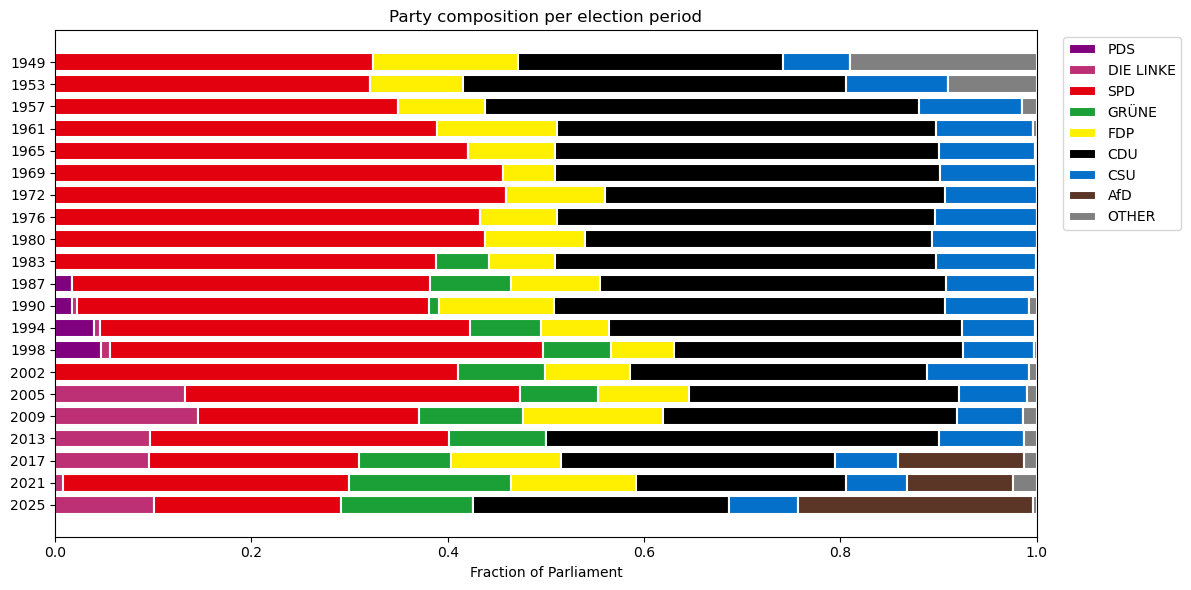

In [5]:
# Handling replacement members and defectors by calculating fraction of time served in parliament
# relative to the full election period:
terms_end_map = wp_mdbs_df.dropna(subset=['MDBWP_UNTIL']).groupby('WP')['MDBWP_UNTIL'].max()
    # Use the latest observed `MDBWP_UNTIL` per WP as the period end, assuming that at least one MDB per WP finishes his term.
terms_end_map.loc[terms_df.loc[terms_df['WP_BEGIN'] == pd.Timestamp('2025-03-25'), 'WP'].iloc[0]] = pd.Timestamp('2026-07-17')
    # WP 21 uses 2026-07-17 (today) as the end date for fraction calculation.
terms_duration_map = (terms_end_map - terms_df.set_index('WP')['WP_BEGIN']).dt.days
    # Calculate duration of each term.
terms_end_dates = wp_mdbs_df['WP'].map(terms_end_map)
wp_end_dates = wp_mdbs_df['MDBWP_UNTIL'].fillna(terms_end_dates)
    # Handle open-ended terms.
wp_duration = (wp_end_dates - wp_mdbs_df['MDBWP_FROM']).dt.days
    # Calculate total duration of each term.
wp_mdbs_df['Frac_of_WP'] = (wp_duration / wp_mdbs_df['WP'].map(terms_duration_map)).astype(float)

# Aggregate fractions per WP and party:
fractions = wp_mdbs_df.groupby(['WP','Party'])['Frac_of_WP'].sum().unstack(fill_value=0)
    # Replace NaNs with 0.

# Normalize rows to 1:
fractions_norm = fractions.div(fractions.sum(axis=1).replace({0:1}), axis=0)
wps = fractions_norm.index.tolist()
y_pos = np.arange(len(wps))

# Plot as 100% stacked bar chart:
fig, ax = plt.subplots(figsize=(12, max(6, int(len(wps)*0.25))))
left = np.zeros(len(wps))
for party in party_colours.keys():
    vals = fractions_norm[party].values
    ax.barh(terms_df['election_y_str'], vals, left=left, color=party_colours.get(party), edgecolor='white', linewidth=1.5)
    left = left + vals
ax.set_xlabel('Fraction of Parliament')
ax.set_title('Party composition per election period')
ax.set_xlim(0,1)
ax.invert_yaxis()  # show earliest WP at the top
ax.legend(party_colours.keys(), bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Gender compositions

In [6]:
# 3.0
def get_gender_ratio(group):
    gender_weight = (
    wp_mdbs_df
    .groupby(group)['Frac_of_WP']
    .sum()
    .unstack(fill_value=0)
    )

    male_share = gender_weight['male'] / gender_weight.sum(axis=1)
    gender_ratio = (-2 * (male_share - 0.5)).rename('gender_ratio').reset_index()
    return terms_df[['WP', 'election_y_int']].merge(gender_ratio, on='WP').sort_values('WP')

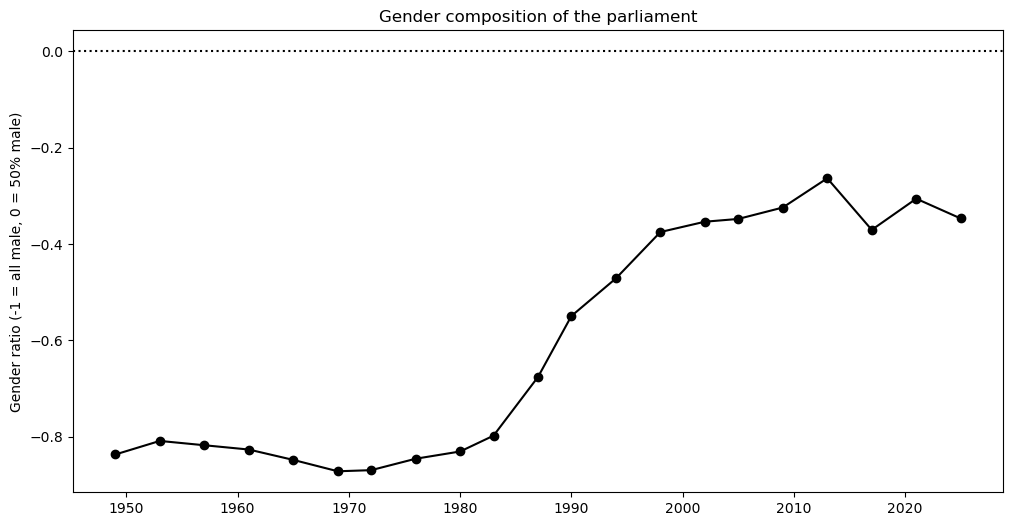

In [7]:
gender_ratio_overall_df = get_gender_ratio(['WP', 'Gender'])

fig, ax = plt.subplots(figsize=(12, max(6, int(len(gender_ratio_overall_df)*0.25))))
ax.axhline(0, color="black", linestyle=':')
ax.plot(gender_ratio_overall_df['election_y_int'], gender_ratio_overall_df['gender_ratio'], marker='o', color='black')
ax.set_ylabel('Gender ratio (-1 = all male, 0 = 50% male)')
ax.set_title('Gender composition of the parliament')
plt.show()

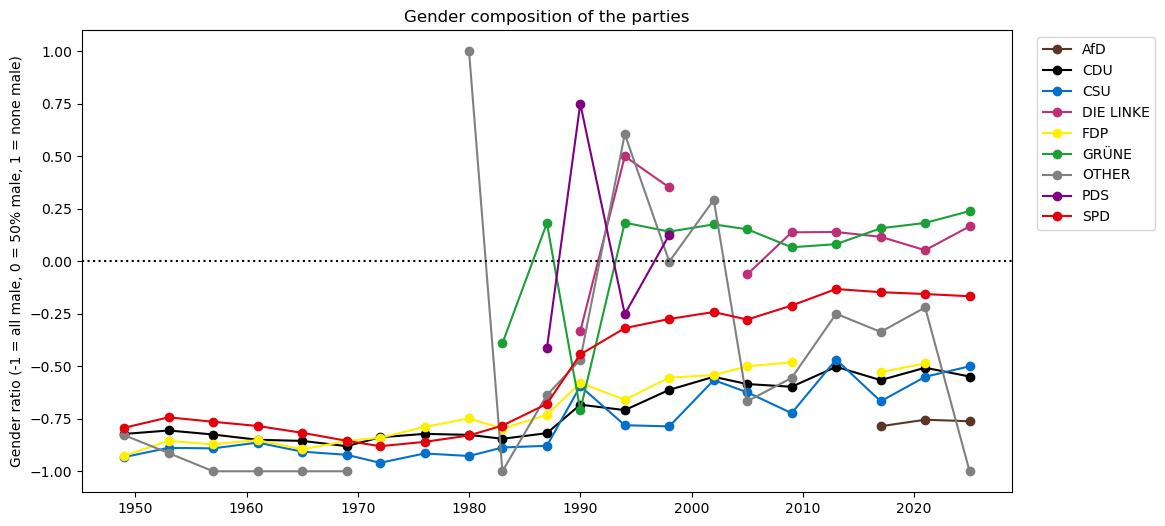

In [16]:
gender_ratio_by_party_df = get_gender_ratio(['WP', 'Party', 'Gender'])

full_terms_order = terms_df[['WP', 'election_y_int']].sort_values('WP').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, max(6, int(full_wp_order.shape[0] * 0.25))))

for party, group in p_df.groupby('Party'):
    # Reindex to the full WP range; missing WPs become NaN and break the line
    group_full = (
        full_wp_order
        .merge(group[['WP', 'gender_ratio']], on='WP', how='left')
    )
    ax.plot(
        group_full['election_y_int'],
        group_full['gender_ratio'],
        marker='o',
        label=party,
        color=party_colours.get(party, 'grey')
    )

ax.set_ylabel('Gender ratio (-1 = all male, 0 = 50% male, 1 = none male)')
ax.set_xlabel('')
ax.set_title('Gender composition of the parties')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.axhline(0, color='black', linestyle=':')
plt.show()